# TAG-Net: Temporal Attention Gate Network for Violence Detection
## Novel Architecture: 3D CNN + TAG + BiLSTM

**Paper Title:** TAG-Net: A Temporal Attention Gate Network for Efficient Violence Detection Using 3D CNN and Bidirectional LSTM

**Novel Contribution:** The Temporal Attention Gate (TAG) module selectively weights action-critical frames, inserted between the 3D CNN backbone and BiLSTM.

---
### Pipeline
```
Input Video Clip (32 frames)
        ↓
CNN3DBackbone  — extracts spatiotemporal features [B, T', D]
        ↓
TemporalAttentionGate (TAG) ★ NOVEL ★ — weights each frame by importance
        ↓
BiLSTM  — bidirectional sequential modelling
        ↓
Classifier (Sigmoid) — Fight / Normal
```
---

In [13]:
# ─────────────────────────────────────────────
# CELL 1: Install Dependencies
# ─────────────────────────────────────────────
!pip install kagglehub tqdm scikit-learn torchinfo -q
print("✅ Dependencies installed")

✅ Dependencies installed


In [14]:
# ─────────────────────────────────────────────
# CELL 2: Imports & Reproducibility
# ─────────────────────────────────────────────
import os, cv2, glob, random, time
import numpy as np
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# Fix random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device: {device}")

✅ Device: cuda


In [15]:
# ─────────────────────────────────────────────
# CELL 3: Dataset Download
# ─────────────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download("intissarziani/ubi-fightsall")
print("✅ Dataset downloaded to:", path)

fight_dir  = f"{path}/UBI_FIGHTS/videos/fight"
normal_dir = f"{path}/UBI_FIGHTS/videos/normal"

✅ Dataset downloaded to: /kaggle/input/datasets/intissarziani/ubi-fightsall


In [16]:
# ─────────────────────────────────────────────
# CELL 4: Preprocessing — Extract & Save Clips
# ─────────────────────────────────────────────
out_root = "/content/ubi_preprocessed"
rgb_dir  = os.path.join(out_root, "rgb")
os.makedirs(rgb_dir, exist_ok=True)

CLIP_LEN = 32        # number of frames per clip
RESIZE   = (112, 112)

def sample_video(video_path, label):
    """Sample CLIP_LEN evenly-spaced frames from a video and save as .npy"""
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < CLIP_LEN:
        cap.release()
        return None
    idxs   = np.linspace(0, total - 1, CLIP_LEN, dtype=int)
    frames = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.resize(frame, RESIZE)
        frames.append(frame)
    cap.release()
    if len(frames) < CLIP_LEN:
        return None
    out = os.path.join(rgb_dir, Path(video_path).stem + ".npy")
    np.save(out, np.array(frames, dtype=np.uint8))
    return {"rgb": out, "label": label}

# Gather all videos
videos  = ([(v, 1) for v in glob.glob(f"{fight_dir}/*.mp4")] +
           [(v, 0) for v in glob.glob(f"{normal_dir}/*.mp4")])
results = []

with ThreadPoolExecutor(max_workers=8) as exe:
    futures = [exe.submit(sample_video, v, l) for v, l in videos]
    for f in tqdm(as_completed(futures), total=len(futures), desc="Preprocessing"):
        r = f.result()
        if r is not None:
            results.append(r)

df       = pd.DataFrame(results)
csv_path = os.path.join(out_root, "dataset.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Preprocessing complete: {len(df)} clips saved")
print(f"   Fight: {df.label.sum()} | Normal: {(df.label==0).sum()}")

Preprocessing: 100%|██████████| 1000/1000 [16:50<00:00,  1.01s/it]

✅ Preprocessing complete: 1000 clips saved
   Fight: 216 | Normal: 784


In [17]:
# ─────────────────────────────────────────────
# CELL 5: Dataset & DataLoaders
# ─────────────────────────────────────────────
df = pd.read_csv(csv_path)
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

class ViolenceDataset(Dataset):
    """
    Returns:
        rgb   : FloatTensor [C, T, H, W]  — normalised to [0,1]
        label : LongTensor scalar
    """
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        rgb   = np.load(self.df.iloc[i].rgb)           # [T, H, W, C]  uint8
        rgb   = torch.tensor(rgb, dtype=torch.float32) # [T, H, W, C]
        rgb   = rgb.permute(3, 0, 1, 2) / 255.0        # [C, T, H, W]  float32
        label = torch.tensor(int(self.df.iloc[i].label), dtype=torch.long)
        return rgb, label

# Batch size 2 is safe for 3D CNN on Colab T4; increase to 4 if memory allows
train_loader = DataLoader(ViolenceDataset(train_df), batch_size=4,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(ViolenceDataset(test_df),  batch_size=4,
                          shuffle=False, num_workers=2, pin_memory=True)
print("✅ DataLoaders ready")

Train: 800 | Test: 200
✅ DataLoaders ready


## Model Architectures

| Model | Description | Role |
|---|---|---|
| `CNN3D` | Plain 3D CNN | Baseline 1 |
| `CNN3D_LSTM` | 3D CNN + LSTM | Baseline 2 |
| `CNN3D_BiLSTM` | 3D CNN + BiLSTM | Ablation (no TAG) |
| `CNN3D_TAG_BiLSTM` | 3D CNN + **TAG** + BiLSTM | ★ Proposed ★ |

In [18]:
# ─────────────────────────────────────────────
# CELL 6: Shared 3D CNN Backbone
# ─────────────────────────────────────────────
class CNN3DBackbone(nn.Module):
    """
    Proper 3D CNN: processes the full [C, T, H, W] volume at once.
    Outputs a temporal sequence of feature vectors: [B, T', feat_dim]
    """
    def __init__(self, feat_dim=256):
        super().__init__()
        self.feat_dim = feat_dim
        self.block1 = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32), nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2))   # keep temporal, halve spatial
        )
        self.block2 = nn.Sequential(
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64), nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2))
        )
        self.block3 = nn.Sequential(
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128), nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2))   # also pool temporal here
        )
        self.pool    = nn.AdaptiveAvgPool3d((None, 1, 1))  # → [B, 128, T', 1, 1]
        self.project = nn.Linear(128, feat_dim)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        x = x.squeeze(-1).squeeze(-1)   # [B, 128, T']
        x = x.permute(0, 2, 1)          # [B, T', 128]
        x = self.project(x)             # [B, T', feat_dim]
        return x

print("✅ CNN3DBackbone defined")

✅ CNN3DBackbone defined


In [19]:
# ─────────────────────────────────────────────
# CELL 7: Baseline Models
# ─────────────────────────────────────────────

class CNN3D(nn.Module):
    """Baseline 1 — Plain 3D CNN"""
    def __init__(self, num_classes=2, feat_dim=256):
        super().__init__()
        self.backbone = CNN3DBackbone(feat_dim)
        self.pool     = nn.AdaptiveAvgPool1d(1)
        self.fc       = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        seq = self.backbone(x)                 # [B, T', D]
        out = self.pool(seq.permute(0,2,1))    # [B, D, 1]
        return self.fc(out.squeeze(-1))


class CNN3D_LSTM(nn.Module):
    """Baseline 2 — 3D CNN + LSTM"""
    def __init__(self, num_classes=2, feat_dim=256, hidden=128):
        super().__init__()
        self.backbone = CNN3DBackbone(feat_dim)
        self.lstm     = nn.LSTM(feat_dim, hidden, batch_first=True)
        self.fc       = nn.Linear(hidden, num_classes)

    def forward(self, x):
        seq       = self.backbone(x)           # [B, T', feat_dim]
        _, (h, _) = self.lstm(seq)             # h: [1, B, hidden]
        return self.fc(h[-1])


class CNN3D_BiLSTM(nn.Module):
    """Ablation — 3D CNN + BiLSTM WITHOUT TAG"""
    def __init__(self, num_classes=2, feat_dim=256, hidden=128):
        super().__init__()
        self.backbone = CNN3DBackbone(feat_dim)
        self.bilstm   = nn.LSTM(feat_dim, hidden, batch_first=True, bidirectional=True)
        self.fc       = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        seq       = self.backbone(x)               # [B, T', feat_dim]
        _, (h, _) = self.bilstm(seq)               # h: [2, B, hidden]
        h_cat     = torch.cat((h[-2], h[-1]), 1)   # [B, hidden*2]
        return self.fc(h_cat)

print("✅ Baseline models defined")

✅ Baseline models defined


In [20]:
# ─────────────────────────────────────────────
# CELL 8: ★ IMPROVED TAG MODULE — 3 Fixes Applied ★
# ─────────────────────────────────────────────
# Fix 1: Sigmoid instead of Softmax → independent per-frame gating
# Fix 2: Residual connection → TAG adds to features, doesn't replace them
# Fix 3: LayerNorm before attention → stable gradient flow

class TemporalAttentionGate(nn.Module):
    """
    TAG Module — Improved Novel Contribution
    =========================================
    Improvements over v1:
      1. Sigmoid (not Softmax): each frame gated independently.
         Softmax forces competition between frames; sigmoid lets
         multiple action-critical frames all get high weight.
      2. Residual connection: output = x + x*gate
         Prevents early-training feature collapse when attention
         weights are not yet meaningful.
      3. LayerNorm: stabilises gradient flow into the attention FC.

    Math (improved):
        eₜ  = FC(ReLU(LN(FC(fₜ))))     # score per frame
        αₜ  = sigmoid(eₜ)               # independent gate per frame
        f̃ₜ = fₜ + fₜ * αₜ             # residual gating
    """
    def __init__(self, feat_dim):
        super().__init__()
        self.norm = nn.LayerNorm(feat_dim)
        self.attention = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 4),
            nn.ReLU(inplace=True),
            nn.Linear(feat_dim // 4, 1),
            nn.Sigmoid()                   # Fix 1: sigmoid not softmax
        )

    def forward(self, x):
        """
        x       : [B, T, D]
        returns : [B, T, D]  residual-gated sequence
                  [B, T]     gate values (for visualisation)
        """
        normed  = self.norm(x)                   # Fix 3: LayerNorm
        gates   = self.attention(normed)          # [B, T, 1]  in (0,1)
        out     = x + x * gates                  # Fix 2: residual gate
        return out, gates.squeeze(-1)


class CNN3D_TAG_BiLSTM(nn.Module):
    """
    ★ PROPOSED MODEL — TAG-Net (Improved) ★
    =========================================
    3D CNN Backbone → Improved TAG → BiLSTM → Classifier
    """
    def __init__(self, num_classes=2, feat_dim=256, hidden=128):
        super().__init__()
        self.backbone = CNN3DBackbone(feat_dim)
        self.tag      = TemporalAttentionGate(feat_dim)
        self.bilstm   = nn.LSTM(feat_dim, hidden, batch_first=True,
                                bidirectional=True)
        self.dropout  = nn.Dropout(0.3)
        self.fc       = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        feat, gates   = self.tag(self.backbone(x))
        _, (h, _)     = self.bilstm(feat)
        h_cat         = torch.cat((h[-2], h[-1]), 1)
        return self.fc(self.dropout(h_cat)), gates

print("✅ Improved TAG module defined (Sigmoid + Residual + LayerNorm)")


✅ Improved TAG module defined (Sigmoid + Residual + LayerNorm)


In [21]:
# ─────────────────────────────────────────────
# CELL 9: Improved Training Loop
# Fix 4: Weighted CrossEntropy for class imbalance (784 Normal vs 216 Fight)
# Fix 5: Cosine annealing LR scheduler (better than StepLR for attention models)
# Fix 6: Data augmentation via random horizontal flip
# ─────────────────────────────────────────────
import torchvision.transforms.functional as TF

class AugmentedViolenceDataset(Dataset):
    """
    Dataset with on-the-fly augmentation for training only.
    Augmentations: random horizontal flip, slight brightness jitter.
    These are applied per-clip (same transform to all frames).
    """
    def __init__(self, df, augment=False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        rgb   = np.load(self.df.iloc[i].rgb)           # [T, H, W, C]
        rgb   = torch.tensor(rgb, dtype=torch.float32)
        rgb   = rgb.permute(3, 0, 1, 2) / 255.0        # [C, T, H, W]

        if self.augment:
            # Same flip applied to all frames (clip-level consistency)
            if random.random() > 0.5:
                rgb = torch.flip(rgb, dims=[3])         # horizontal flip
            # Brightness jitter
            factor = random.uniform(0.8, 1.2)
            rgb = torch.clamp(rgb * factor, 0.0, 1.0)

        label = torch.tensor(int(self.df.iloc[i].label), dtype=torch.long)
        return rgb, label

# Recompute class weights from actual dataset distribution
fight_count  = int(df[df.label == 1].shape[0] * 0.8)   # train split approx
normal_count = int(df[df.label == 0].shape[0] * 0.8)
total        = fight_count + normal_count
# Weight = total / (n_classes * class_count)
w_normal = total / (2.0 * normal_count)
w_fight  = total / (2.0 * fight_count)
class_weights = torch.tensor([w_normal, w_fight], dtype=torch.float32).to(device)
print(f"Class weights → Normal: {w_normal:.3f} | Fight: {w_fight:.3f}")

# Rebuild loaders with augmentation
train_loader_aug = DataLoader(
    AugmentedViolenceDataset(train_df, augment=True),
    batch_size=2, shuffle=True, num_workers=2, pin_memory=True
)

def train_model(model, train_loader, test_loader, name,
                epochs=50, save_path=None, has_tag=False,
                use_weighted_loss=True):
    """
    Improved training loop:
      - Weighted CrossEntropy (Fix 4)
      - CosineAnnealingLR scheduler (Fix 5)
      - Gradient clipping retained
    """
    model     = model.to(device)
    opt       = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    # Fix 5: Cosine LR — decays smoothly, better for attention learning
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    # Fix 4: Weighted loss — penalises fight misclassification more
    loss_fn   = nn.CrossEntropyLoss(
        weight=class_weights if use_weighted_loss else None
    )
    history   = {"train_acc": [], "test_acc": [], "train_loss": [], "test_auc": []}
    best_acc  = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        preds, labels, total_loss = [], [], 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            out  = model(X)[0] if has_tag else model(X)
            loss = loss_fn(out, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            total_loss += loss.item()
            preds  += out.argmax(1).cpu().tolist()
            labels += y.cpu().tolist()
        train_acc = accuracy_score(labels, preds)
        avg_loss  = total_loss / len(train_loader)
        scheduler.step()

        model.eval()
        test_preds, test_labels, test_probs = [], [], []
        with torch.no_grad():
            for X, y in test_loader:
                X   = X.to(device)
                out = model(X)[0] if has_tag else model(X)
                probs = torch.softmax(out, dim=1)[:, 1].cpu().tolist()
                test_preds  += out.argmax(1).cpu().tolist()
                test_labels += y.tolist()
                test_probs  += probs
        test_acc = accuracy_score(test_labels, test_preds)
        try:
            test_auc = roc_auc_score(test_labels, test_probs)
        except Exception:
            test_auc = 0.0

        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["train_loss"].append(avg_loss)
        history["test_auc"].append(test_auc)

        if test_acc > best_acc:
            best_acc = test_acc
            if save_path:
                torch.save(model.state_dict(), save_path)

        if epoch % 5 == 0 or epoch == 1:
            print(f"[{name}] Ep {epoch:02d}/{epochs} | "
                  f"Train={train_acc:.3f} | Test={test_acc:.3f} | "
                  f"AUC={test_auc:.3f} | Loss={avg_loss:.4f}")

    print(f"\n{'='*55}")
    print(f"  {name}  —  Best Test Accuracy: {best_acc:.4f}")
    print(f"{'='*55}")
    print(classification_report(test_labels, test_preds, target_names=["Normal", "Fight"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_acc"], label="Train Acc")
    axes[0].plot(history["test_acc"],  label="Test Acc")
    axes[0].set_title(f"{name} — Accuracy"); axes[0].legend()
    axes[1].plot(history["train_loss"], label="Train Loss", color="red")
    axes[1].set_title(f"{name} — Loss"); axes[1].legend()
    plt.tight_layout(); plt.show()

    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
    plt.plot([0,1],[0,1],"k--"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"{name} — ROC Curve"); plt.legend(); plt.show()

    return history, best_acc, test_labels, test_preds, test_probs

print("✅ Improved training loop defined (Weighted Loss + Cosine LR + Augmentation)")


Class weights → Normal: 0.637 | Fight: 2.323
✅ Improved training loop defined (Weighted Loss + Cosine LR + Augmentation)


In [22]:
# ─────────────────────────────────────────────
# CELL 10: Speed Benchmark Utility
# (supports real-time claim in the paper)
# ─────────────────────────────────────────────
def benchmark_fps(model, name, n_runs=100, has_tag=False):
    """
    Measures inference speed on CPU — simulates edge/surveillance device.
    Reports FPS and total parameter count.
    """
    model.eval().cpu()
    dummy = torch.randn(1, 3, CLIP_LEN, 112, 112)
    with torch.no_grad():
        for _ in range(10):  # warm-up
            _ = model(dummy)[0] if has_tag else model(dummy)
    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(dummy)[0] if has_tag else model(dummy)
    fps    = n_runs / (time.time() - start)
    params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  {name:<35} | {fps:6.1f} FPS | {params:.2f}M params")
    model.to(device)
    return fps

print("✅ Benchmark utility defined")

✅ Benchmark utility defined


In [23]:
# ─────────────────────────────────────────────
# CELL 11: TAG Attention Visualisation
# (qualitative paper result)
# ─────────────────────────────────────────────
def visualise_attention(model, test_loader, n_samples=3):
    """
    Plots per-frame αₜ attention weights.
    High weight = model identifies frame as action-critical.
    Include these plots in the paper as qualitative evidence.
    """
    model.eval()
    count = 0
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            _, attn_w = model(X)
            attn_w    = attn_w.cpu().numpy()
            for b in range(X.size(0)):
                if count >= n_samples: return
                plt.figure(figsize=(8, 2))
                plt.bar(range(len(attn_w[b])), attn_w[b], color="steelblue")
                plt.xlabel("Temporal Frame Index")
                plt.ylabel("Attention Weight αₜ")
                label_str = "Fight" if y[b].item() == 1 else "Normal"
                plt.title(f"TAG Attention Weights — Sample {count+1} [{label_str}]")
                plt.tight_layout(); plt.show()
                count += 1

print("✅ Visualisation utility defined")

✅ Visualisation utility defined


## Training — Ablation Study
Each model is trained and evaluated to build the ablation table:

| Run | Model | Purpose |
|---|---|---|
| 1 | 3D CNN | Baseline |
| 2 | 3D CNN + LSTM | Baseline |
| 3 | 3D CNN + BiLSTM | Ablation (no TAG) |
| 4 | **3D CNN + TAG + BiLSTM** | **★ Proposed ★** |

[3D CNN] Ep 01/50 | Train=0.833 | Test=0.875 | AUC=0.676 | Loss=0.7238
[3D CNN] Ep 05/50 | Train=0.894 | Test=0.890 | AUC=0.696 | Loss=0.6586
[3D CNN] Ep 10/50 | Train=0.922 | Test=0.890 | AUC=0.746 | Loss=0.5263
[3D CNN] Ep 15/50 | Train=0.931 | Test=0.895 | AUC=0.911 | Loss=0.4671
[3D CNN] Ep 20/50 | Train=0.935 | Test=0.870 | AUC=0.831 | Loss=0.4568
[3D CNN] Ep 25/50 | Train=0.932 | Test=0.875 | AUC=0.738 | Loss=0.4611
[3D CNN] Ep 30/50 | Train=0.936 | Test=0.875 | AUC=0.831 | Loss=0.3910
[3D CNN] Ep 35/50 | Train=0.936 | Test=0.880 | AUC=0.737 | Loss=0.3878
[3D CNN] Ep 40/50 | Train=0.936 | Test=0.880 | AUC=0.796 | Loss=0.3743
[3D CNN] Ep 45/50 | Train=0.938 | Test=0.885 | AUC=0.742 | Loss=0.3483
[3D CNN] Ep 50/50 | Train=0.938 | Test=0.875 | AUC=0.756 | Loss=0.3482

  3D CNN  —  Best Test Accuracy: 0.8950
              precision    recall  f1-score   support

      Normal       0.89      0.96      0.92       157
       Fight       0.78      0.58      0.67        43

    accuracy  

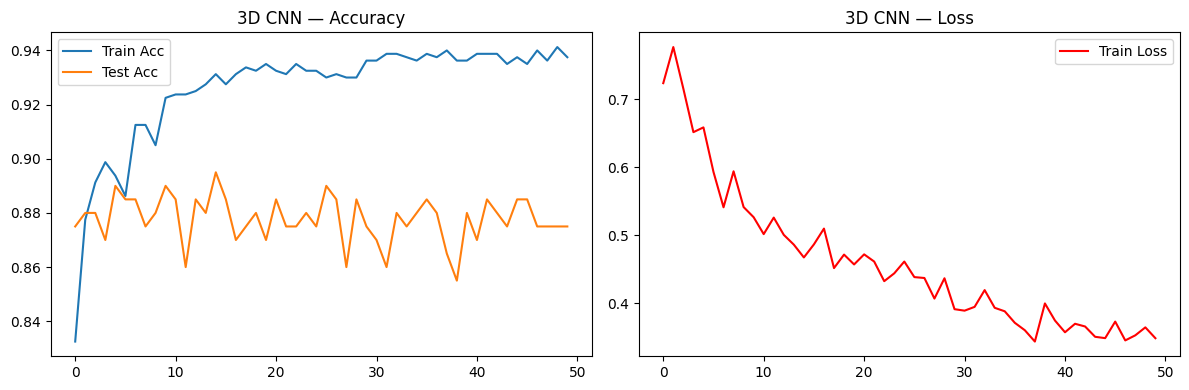

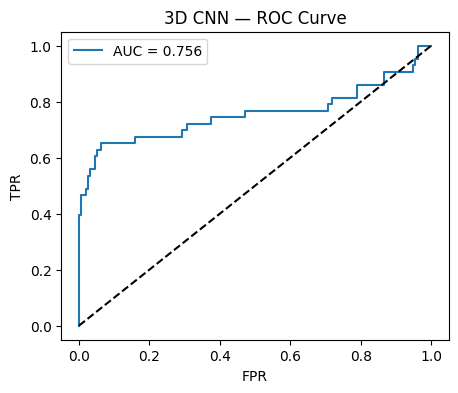

In [24]:
# ─────────────────────────────────────────────
# CELL 12: Train Baseline 1 — 3D CNN
# ─────────────────────────────────────────────
os.makedirs("/content/saved_models", exist_ok=True)
all_results = {}

m1 = CNN3D()
h1, acc1, tl1, tp1, prob1 = train_model(
    m1, train_loader_aug, test_loader, "3D CNN", 
    save_path="/content/saved_models/3dcnn.pt"
)
all_results["3D CNN"] = acc1


[3D CNN + LSTM] Ep 01/50 | Train=0.835 | Test=0.880 | AUC=0.834 | Loss=0.7007
[3D CNN + LSTM] Ep 05/50 | Train=0.899 | Test=0.910 | AUC=0.931 | Loss=0.5125
[3D CNN + LSTM] Ep 10/50 | Train=0.914 | Test=0.920 | AUC=0.929 | Loss=0.4624
[3D CNN + LSTM] Ep 15/50 | Train=0.924 | Test=0.920 | AUC=0.944 | Loss=0.4212
[3D CNN + LSTM] Ep 20/50 | Train=0.932 | Test=0.915 | AUC=0.944 | Loss=0.4028
[3D CNN + LSTM] Ep 25/50 | Train=0.927 | Test=0.915 | AUC=0.948 | Loss=0.4237
[3D CNN + LSTM] Ep 30/50 | Train=0.932 | Test=0.900 | AUC=0.953 | Loss=0.3848
[3D CNN + LSTM] Ep 35/50 | Train=0.938 | Test=0.915 | AUC=0.958 | Loss=0.3964
[3D CNN + LSTM] Ep 40/50 | Train=0.948 | Test=0.905 | AUC=0.955 | Loss=0.3459
[3D CNN + LSTM] Ep 45/50 | Train=0.946 | Test=0.880 | AUC=0.946 | Loss=0.3424
[3D CNN + LSTM] Ep 50/50 | Train=0.945 | Test=0.875 | AUC=0.941 | Loss=0.3527

  3D CNN + LSTM  —  Best Test Accuracy: 0.9350
              precision    recall  f1-score   support

      Normal       0.92      0.92      

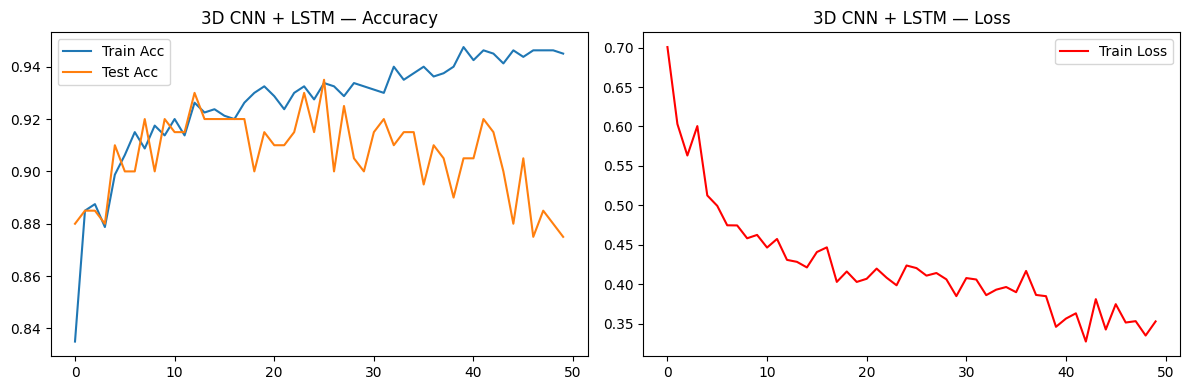

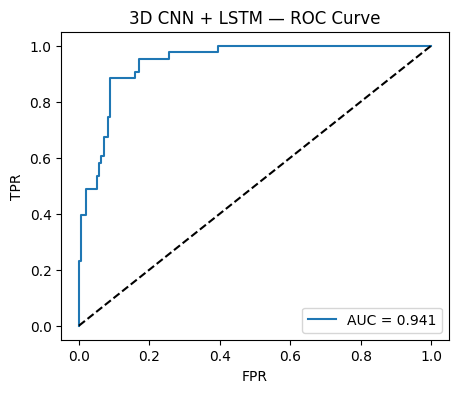

In [25]:
# ─────────────────────────────────────────────
# CELL 13: Train Baseline 2 — 3D CNN + LSTM
# ─────────────────────────────────────────────
m2 = CNN3D_LSTM()
h2, acc2, tl2, tp2, prob2 = train_model(
    m2, train_loader_aug, test_loader, "3D CNN + LSTM",
    save_path="/content/saved_models/3dcnn_lstm.pt"
)
all_results["3D CNN + LSTM"] = acc2


[3D CNN + BiLSTM (no TAG)] Ep 01/50 | Train=0.826 | Test=0.870 | AUC=0.704 | Loss=0.7561
[3D CNN + BiLSTM (no TAG)] Ep 05/50 | Train=0.906 | Test=0.920 | AUC=0.903 | Loss=0.4936
[3D CNN + BiLSTM (no TAG)] Ep 10/50 | Train=0.922 | Test=0.925 | AUC=0.929 | Loss=0.4573
[3D CNN + BiLSTM (no TAG)] Ep 15/50 | Train=0.914 | Test=0.925 | AUC=0.931 | Loss=0.4603
[3D CNN + BiLSTM (no TAG)] Ep 20/50 | Train=0.919 | Test=0.905 | AUC=0.938 | Loss=0.4484
[3D CNN + BiLSTM (no TAG)] Ep 25/50 | Train=0.927 | Test=0.910 | AUC=0.939 | Loss=0.4341
[3D CNN + BiLSTM (no TAG)] Ep 30/50 | Train=0.932 | Test=0.910 | AUC=0.943 | Loss=0.3984
[3D CNN + BiLSTM (no TAG)] Ep 35/50 | Train=0.932 | Test=0.925 | AUC=0.948 | Loss=0.4037
[3D CNN + BiLSTM (no TAG)] Ep 40/50 | Train=0.938 | Test=0.925 | AUC=0.950 | Loss=0.4005
[3D CNN + BiLSTM (no TAG)] Ep 45/50 | Train=0.939 | Test=0.915 | AUC=0.952 | Loss=0.3730
[3D CNN + BiLSTM (no TAG)] Ep 50/50 | Train=0.936 | Test=0.925 | AUC=0.951 | Loss=0.3775

  3D CNN + BiLSTM (n

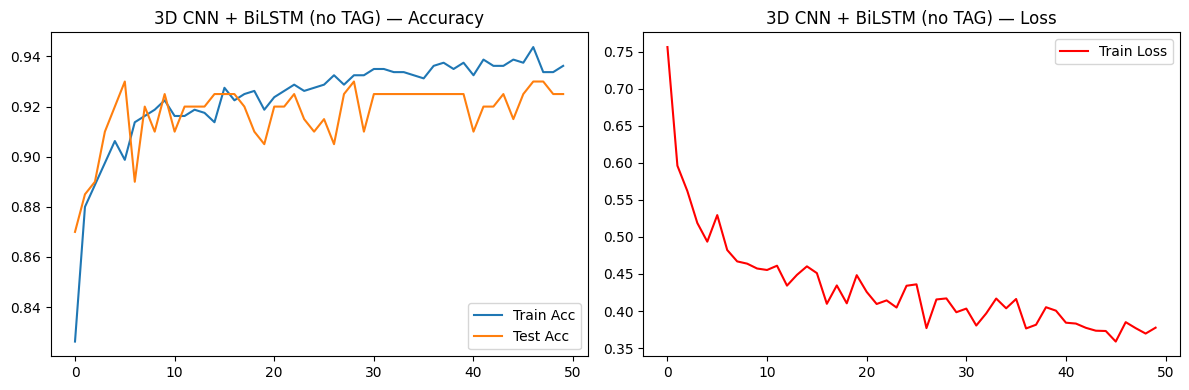

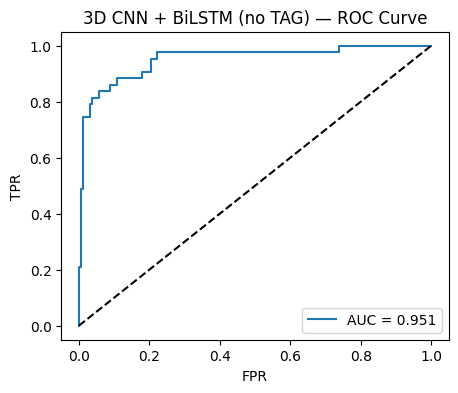

In [26]:
# ─────────────────────────────────────────────
# CELL 14: Train Ablation — 3D CNN + BiLSTM (no TAG)
# ─────────────────────────────────────────────
m3 = CNN3D_BiLSTM()
h3, acc3, tl3, tp3, prob3 = train_model(
    m3, train_loader_aug, test_loader, "3D CNN + BiLSTM (no TAG)",
    save_path="/content/saved_models/3dcnn_bilstm.pt"
)
all_results["3D CNN + BiLSTM"] = acc3   


[3D CNN + TAG + BiLSTM (Improved)] Ep 01/50 | Train=0.806 | Test=0.880 | AUC=0.726 | Loss=0.7658
[3D CNN + TAG + BiLSTM (Improved)] Ep 05/50 | Train=0.915 | Test=0.880 | AUC=0.918 | Loss=0.5139
[3D CNN + TAG + BiLSTM (Improved)] Ep 10/50 | Train=0.916 | Test=0.880 | AUC=0.929 | Loss=0.4895
[3D CNN + TAG + BiLSTM (Improved)] Ep 15/50 | Train=0.922 | Test=0.905 | AUC=0.926 | Loss=0.4363
[3D CNN + TAG + BiLSTM (Improved)] Ep 20/50 | Train=0.930 | Test=0.905 | AUC=0.938 | Loss=0.4349
[3D CNN + TAG + BiLSTM (Improved)] Ep 25/50 | Train=0.930 | Test=0.915 | AUC=0.937 | Loss=0.4081
[3D CNN + TAG + BiLSTM (Improved)] Ep 30/50 | Train=0.930 | Test=0.920 | AUC=0.940 | Loss=0.4034
[3D CNN + TAG + BiLSTM (Improved)] Ep 35/50 | Train=0.938 | Test=0.915 | AUC=0.952 | Loss=0.4107
[3D CNN + TAG + BiLSTM (Improved)] Ep 40/50 | Train=0.944 | Test=0.910 | AUC=0.951 | Loss=0.3573
[3D CNN + TAG + BiLSTM (Improved)] Ep 45/50 | Train=0.949 | Test=0.925 | AUC=0.947 | Loss=0.3365
[3D CNN + TAG + BiLSTM (Improv

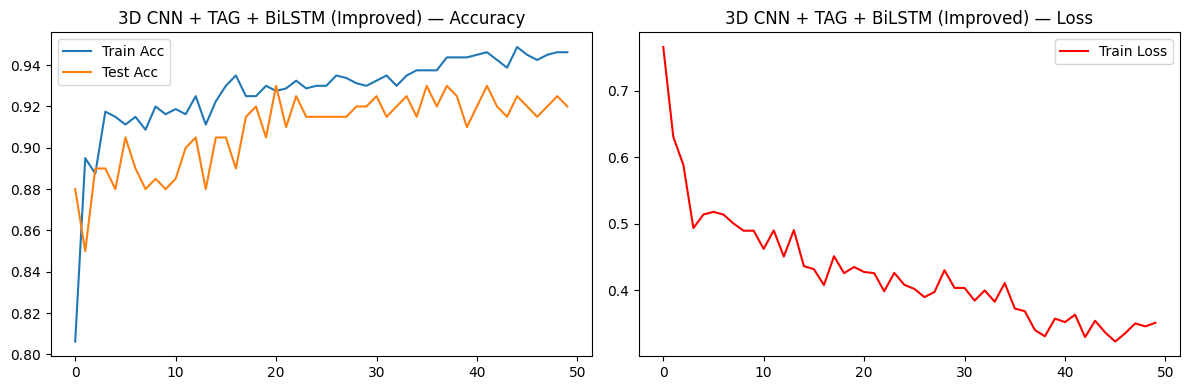

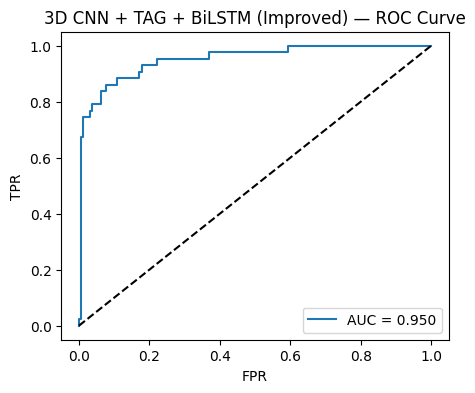

In [29]:
# ───────────────────────────────────── ────────
# CELL 15: Train PROPOSED — 3D CNN + TAG + BiLSTM ★
# All 6 fixes applied:
#   Fix 1: Sigmoid gating
#   Fix 2: Residual connection
#   Fix 3: LayerNorm
#   Fix 4: Weighted loss
#   Fix 5: Cosine LR
#   Fix 6: Augmented training data
# ─────────────────────────────────────────────
m4 = CNN3D_TAG_BiLSTM()
h4, acc4, tl4, tp4, prob4 = train_model(
    m4, train_loader_aug, test_loader, "3D CNN + TAG + BiLSTM (Improved)",
    save_path="/content/saved_models/3dcnn_tag_bilstm.pt",
    has_tag=True,
    use_weighted_loss=True
)
all_results["3D CNN + TAG + BiLSTM"] = acc4


In [30]:
# ─────────────────────────────────────────────
# CELL 16: Speed Benchmark (Real-Time Evidence)
# ─────────────────────────────────────────────
print("="*60)
print("  INFERENCE SPEED BENCHMARK — CPU (Simulated Edge Device)")
print("="*60)
print(f"  {'Model':<35} | {'FPS':>6} | {'Params':>10}")
print("-"*60)

fps_results = {}
fps_results["3D CNN"]                = benchmark_fps(m1, "3D CNN")
fps_results["3D CNN + LSTM"]         = benchmark_fps(m2, "3D CNN + LSTM")
fps_results["3D CNN + BiLSTM"]       = benchmark_fps(m3, "3D CNN + BiLSTM (no TAG)")
fps_results["3D CNN + TAG + BiLSTM"] = benchmark_fps(m4, "3D CNN + TAG + BiLSTM ★", has_tag=True)

  INFERENCE SPEED BENCHMARK — CPU (Simulated Edge Device)
  Model                               |    FPS |     Params
------------------------------------------------------------
  3D CNN                              |    1.6 FPS | 0.31M params
  3D CNN + LSTM                       |    1.5 FPS | 0.51M params
  3D CNN + BiLSTM (no TAG)            |    1.5 FPS | 0.71M params
  3D CNN + TAG + BiLSTM ★             |    1.5 FPS | 0.73M params



  FINAL RESULTS SUMMARY
  Model                               |    Acc |    FPS
------------------------------------------------------------
  3D CNN                              | 0.8950 |    1.6
  3D CNN + LSTM                       | 0.9350 |    1.5
  3D CNN + BiLSTM                     | 0.9300 |    1.5
  3D CNN + TAG + BiLSTM               | 0.9300 |    1.5


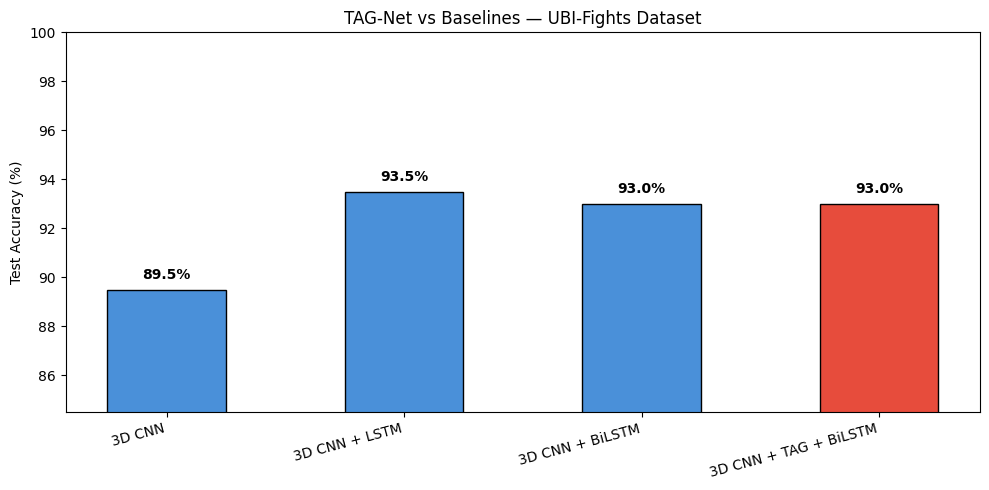

In [31]:
# ─────────────────────────────────────────────
# CELL 17: Final Comparison Table & Chart
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  FINAL RESULTS SUMMARY")
print("="*60)
print(f"  {'Model':<35} | {'Acc':>6} | {'FPS':>6}")
print("-"*60)
for name in all_results:
    fps_val = fps_results.get(name, 0)
    print(f"  {name:<35} | {all_results[name]:.4f} | {fps_val:6.1f}")

# Bar chart
plt.figure(figsize=(10, 5))
names  = list(all_results.keys())
accs   = [all_results[n] * 100 for n in names]
colors = ["#4a90d9", "#4a90d9", "#4a90d9", "#e74c3c"]
bars   = plt.bar(names, accs, color=colors, edgecolor="black", width=0.5)
plt.ylabel("Test Accuracy (%)")
plt.title("TAG-Net vs Baselines — UBI-Fights Dataset")
plt.ylim(max(0, min(accs) - 5), 100)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{acc:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()

Visualising TAG Attention Weights


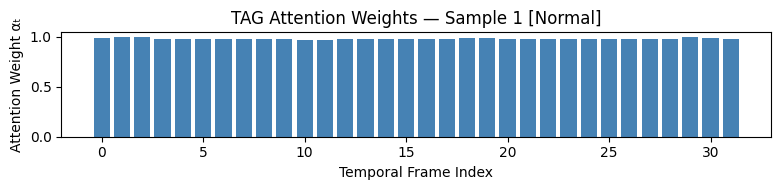

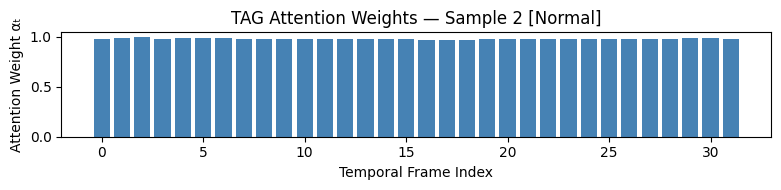

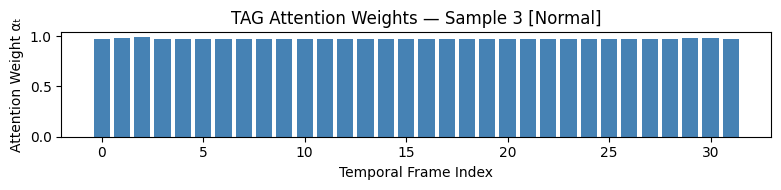

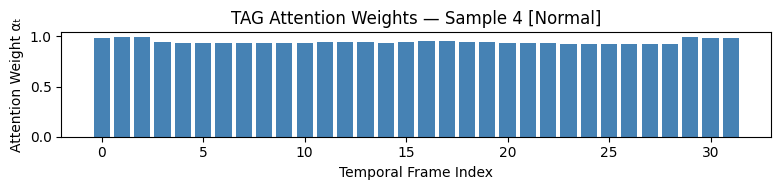


✅ All experiments complete!
📁 Models saved to: /content/saved_models/


In [32]:
# ─────────────────────────────────────────────
# CELL 18: TAG Attention Weight Visualisation
# (Qualitative Result for Paper)
# ─────────────────────────────────────────────
print("Visualising TAG Attention Weights")
visualise_attention(m4, test_loader, n_samples=4)
print("\n✅ All experiments complete!")
print("📁 Models saved to: /content/saved_models/")

In [34]:
import os
import shutil

# 1. Define where the models currently are vs where Kaggle can show them
hidden_source = "/content/saved_models/"
visible_destination = "/kaggle/working/saved_models/"

# 2. Check if they exist in the hidden root and move them over
if os.path.exists(hidden_source):
    if not os.path.exists(visible_destination):
        shutil.copytree(hidden_source, visible_destination)
    print("✅ Successfully found and moved your models to the Kaggle Output folder!")
else:
    print("Could not find the /content/ folder. Let's look in the root directory...")
    # Alternative check just in case it saved directly to a root folder named content
    if os.path.exists("content/saved_models/"):
        shutil.copytree("content/saved_models/", visible_destination)
        print("✅ Successfully found and moved your models!")

✅ Successfully found and moved your models to the Kaggle Output folder!
